# Model Comparison: Decision Tree vs. Logistic Regression

This notebook provides a **head-to-head comparison** of two classifiers built from scratch to predict whether a bank customer will subscribe to a term deposit.

| | Decision Tree | Logistic Regression |
|---|---|---|
| **Core idea** | Recursive binary splits on features | Linear decision boundary via sigmoid |
| **Learning algorithm** | Greedy Gini impurity minimisation | Gradient descent on BCE loss |
| **Non-linearity** | Piecewise-constant (axis-aligned regions) | None — single hyperplane |
| **Interpretability** | Tree rules + MDI feature importance | Weights as direct log-odds contributions |
| **Regularisation** | `max_depth`, `min_samples_split` | L2 penalty ($\lambda$) |

**Evaluation protocol (identical for both models)**
- Same stratified 64 % / 16 % / 20 % train / val / test split (seed 42)
- Optimisation target: **F2-score** (β=2) — Recall weighted 4× over Precision
- Threshold tuned on the **validation set**, final metrics reported on the **test set** only

## Step 1: Imports, Data Loading, and Shared Split

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Load dataset ─────────────────────────────────────────────────────────────
df = pd.read_csv('cleaned_data.csv')

X_raw = df.drop(columns=['y', 'y_binary']).copy()
y_all = df['y_binary'].values

for col in X_raw.columns:
    if X_raw[col].dtype == 'bool':
        X_raw[col] = X_raw[col].astype(float)

X_all         = X_raw.values.astype(float)
feature_names = list(X_raw.columns)

print(f"Dataset: {X_all.shape[0]:,} samples, {X_all.shape[1]} features")
print(f"Positive rate: {y_all.mean():.3f}  ({int(y_all.sum())} subscribers / {len(y_all)} total)")

# ── Stratified 64 / 16 / 20 split (identical seed for both models) ───────────
pos_idx = np.where(y_all == 1)[0]
neg_idx = np.where(y_all == 0)[0]

np.random.seed(42)
np.random.shuffle(pos_idx)
np.random.shuffle(neg_idx)

n_pos_test = int(len(pos_idx) * 0.2);  n_neg_test = int(len(neg_idx) * 0.2)
test_idx   = np.concatenate([pos_idx[:n_pos_test],  neg_idx[:n_neg_test]])

pos_rem = pos_idx[n_pos_test:];  neg_rem = neg_idx[n_neg_test:]
n_pos_val = int(len(pos_rem) * 0.2);  n_neg_val = int(len(neg_rem) * 0.2)
val_idx   = np.concatenate([pos_rem[:n_pos_val], neg_rem[:n_neg_val]])
train_idx = np.concatenate([pos_rem[n_pos_val:], neg_rem[n_neg_val:]])

X_train, y_train = X_all[train_idx], y_all[train_idx]
X_val,   y_val   = X_all[val_idx],   y_all[val_idx]
X_test,  y_test  = X_all[test_idx],  y_all[test_idx]

print(f"\nTrain : {len(y_train):>6}  (pos rate {y_train.mean():.3f})")
print(f"Val   : {len(y_val):>6}  (pos rate {y_val.mean():.3f})")
print(f"Test  : {len(y_test):>6}  (pos rate {y_test.mean():.3f})")

## Step 2: Shared Helper Functions

Metric computation and threshold sweeping are used identically for both models.

In [23]:
def cm_counts(y_true, y_pred):
    TP = int(((y_pred == 1) & (y_true == 1)).sum())
    FP = int(((y_pred == 1) & (y_true == 0)).sum())
    TN = int(((y_pred == 0) & (y_true == 0)).sum())
    FN = int(((y_pred == 0) & (y_true == 1)).sum())
    return TP, FP, TN, FN

def metrics(y_true, y_pred):
    TP, FP, TN, FN = cm_counts(y_true, y_pred)
    acc  = (TP + TN) / (TP + FP + TN + FN)
    prec = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    rec  = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1   = 2  * prec * rec / (prec + rec)      if (prec + rec)     > 0 else 0.0
    f2   = 5  * prec * rec / (4 * prec + rec)  if (4*prec + rec)   > 0 else 0.0
    return dict(acc=acc, prec=prec, rec=rec, f1=f1, f2=f2,
                TP=TP, FP=FP, TN=TN, FN=FN)

def best_threshold_f2(y_true, proba, n_steps=200):
    """Return the threshold that maximises F2 on the given set."""
    thresholds = np.linspace(0.0, 1.0, n_steps)
    best_t, best_f2 = 0.5, 0.0
    for t in thresholds:
        m = metrics(y_true, (proba >= t).astype(int))
        if m["f2"] > best_f2:
            best_f2 = m["f2"]
            best_t  = t
    return best_t, best_f2

def pr_roc_curves(y_true, proba, n_steps=200):
    """Return arrays for PR and ROC curves."""
    thresholds = np.linspace(0.0, 1.0, n_steps)
    prec_list, rec_list, fpr_list = [], [], []
    for t in thresholds:
        TP, FP, TN, FN = cm_counts(y_true, (proba >= t).astype(int))
        prec_list.append(TP / (TP + FP) if (TP + FP) > 0 else 1.0)
        rec_list.append( TP / (TP + FN) if (TP + FN) > 0 else 0.0)
        fpr_list.append( FP / (FP + TN) if (FP + TN) > 0 else 0.0)
    prec = np.array(prec_list)
    rec  = np.array(rec_list)
    fpr  = np.array(fpr_list)
    # AUC via trapezoidal rule
    sort_pr  = np.argsort(rec);  auc_pr  = float(np.trapezoid(prec[sort_pr],  rec[sort_pr]))
    sort_roc = np.argsort(fpr);  auc_roc = float(np.trapezoid(rec[sort_roc],  fpr[sort_roc]))
    return prec, rec, fpr, auc_pr, auc_roc

print("Helper functions defined.")

Helper functions defined.


## Step 3: Decision Tree — Implementation and Training

Full from-scratch implementation with weighted Gini impurity, balanced class weights, and 2D grid search (max_depth × min_samples_split) optimised for F2 on the validation set.

In [24]:
class DecisionTree:
    def __init__(self, max_depth=5, min_samples_split=10, class_weight=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.class_weight = class_weight
        self.tree = None
        self.class_weight_ = {}

    def gini(self, y, w=None):
        if len(y) == 0: return 0.0
        if w is None: w = np.ones(len(y))
        total_w = w.sum()
        if total_w == 0: return 0.0
        p1 = w[y == 1].sum() / total_w
        return 1.0 - (p1**2 + (1 - p1)**2)

    def split_dataset(self, X, y, feature, threshold, w=None):
        mask = X[:, feature] <= threshold
        if w is not None:
            return X[mask], y[mask], w[mask], X[~mask], y[~mask], w[~mask]
        return X[mask], y[mask], None, X[~mask], y[~mask], None

    def best_split(self, X, y, w):
        n, d = X.shape
        w_total = w.sum()
        best_gini, best_info = float('inf'), None
        for feature in range(d):
            unique_vals = np.unique(X[:, feature])
            if len(unique_vals) < 2: continue
            for threshold in (unique_vals[:-1] + unique_vals[1:]) / 2.0:
                Xl, yl, wl, Xr, yr, wr = self.split_dataset(X, y, feature, threshold, w)
                if len(yl) == 0 or len(yr) == 0: continue
                g = (wl.sum() / w_total) * self.gini(yl, wl) + \
                    (wr.sum() / w_total) * self.gini(yr, wr)
                if g < best_gini:
                    best_gini = g
                    best_info = dict(feature=feature, threshold=threshold,
                                     gini_split=g,
                                     Xl=Xl, yl=yl, wl=wl, Xr=Xr, yr=yr, wr=wr)
        return best_info

    def build_tree(self, X, y, depth=0, sw=None):
        n = len(y)
        w = sw if sw is not None else np.ones(n)
        w0, w1 = self.class_weight_.get(0, 1.0), self.class_weight_.get(1, 1.0)
        wpos = w1 * float((y == 1).sum())
        wneg = w0 * float((y == 0).sum())
        prob = wpos / (wpos + wneg) if (wpos + wneg) > 0 else 0.0
        label = int(np.bincount(y.astype(int), weights=w).argmax())

        if depth >= self.max_depth or n < self.min_samples_split or self.gini(y, w) == 0:
            return {"label": label, "prob": prob}
        split = self.best_split(X, y, w)
        if split is None:
            return {"label": label, "prob": prob}
        cur_gini = self.gini(y, w)
        return {
            "feature": split["feature"], "threshold": split["threshold"],
            "n_samples": n, "gini_gain": cur_gini - split["gini_split"],
            "left":  self.build_tree(split["Xl"], split["yl"], depth + 1, split["wl"]),
            "right": self.build_tree(split["Xr"], split["yr"], depth + 1, split["wr"]),
        }

    def fit(self, X, y):
        n, classes = len(y), np.unique(y)
        if self.class_weight == 'balanced':
            self.class_weight_ = {c: n / (len(classes) * np.sum(y == c)) for c in classes}
        elif isinstance(self.class_weight, dict):
            self.class_weight_ = self.class_weight
        else:
            self.class_weight_ = {c: 1.0 for c in classes}
        sw = np.array([self.class_weight_[yi] for yi in y])
        self.tree = self.build_tree(X, y, depth=0, sw=sw)

    def _traverse(self, sample):
        node = self.tree
        while "label" not in node:
            node = node["left"] if sample[node["feature"]] <= node["threshold"] else node["right"]
        return node

    def predict_proba(self, X):
        return np.array([self._traverse(s)["prob"] for s in X])

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


# ── 2D grid search on validation set (F2 criterion) ─────────────────────────
depths      = [7, 9, 11]
min_samples = [10, 20, 50, 100, 200]
best_val_f2, best_params = 0.0, (9, 100)

print(f"  {'depth':>5}  {'min_s':>5}  {'Val F2':>8}")
for d in depths:
    for ms in min_samples:
        dt_tmp = DecisionTree(max_depth=d, min_samples_split=ms, class_weight='balanced')
        dt_tmp.fit(X_train, y_train)
        f2 = metrics(y_val, dt_tmp.predict(X_val))["f2"]
        marker = "  ← best" if f2 > best_val_f2 else ""
        if f2 > best_val_f2:
            best_val_f2 = f2
            best_params = (d, ms)
        print(f"  {d:>5}  {ms:>5}  {f2:>8.4f}{marker}")

best_depth, best_mss = best_params
print(f"\nBest: max_depth={best_depth}, min_samples_split={best_mss}  (val F2={best_val_f2:.4f})")

# ── Train final DT ────────────────────────────────────────────────────────────
dt = DecisionTree(max_depth=best_depth, min_samples_split=best_mss, class_weight='balanced')
dt.fit(X_train, y_train)
print("Decision Tree trained.")

  depth  min_s    Val F2
      7     10    0.4955  ← best
      7     20    0.4964  ← best
      7     50    0.4981  ← best
      7    100    0.4984  ← best
      7    200    0.4971
      9     10    0.5007  ← best
      9     20    0.5020  ← best
      9     50    0.5059  ← best
      9    100    0.5105  ← best
      9    200    0.5044
     11     10    0.4808
     11     20    0.4838
     11     50    0.4893
     11    100    0.4932
     11    200    0.4940

Best: max_depth=9, min_samples_split=100  (val F2=0.5105)
Decision Tree trained.


## Step 4: Logistic Regression — Implementation and Training

Gradient descent with class-weighted BCE loss and L2 regularisation. Post-split standardisation on continuous features (training statistics only). The model is trained on the same 64 % training set.

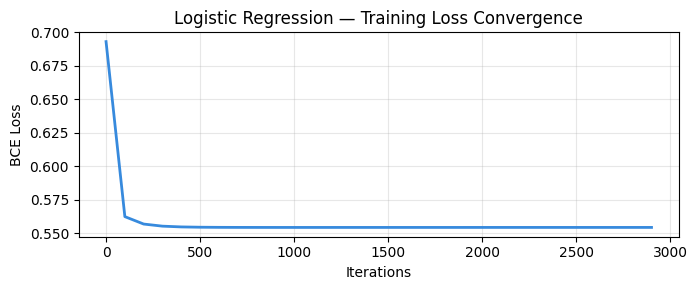

Logistic Regression trained.


In [25]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def train_lr(X_tr, y_tr, lr=0.5, iters=3000, lam=0.01):
    n, d = X_tr.shape
    w = np.zeros((d, 1))
    pos = (y_tr == 1).sum(); neg = (y_tr == 0).sum()
    cw  = np.where(y_tr.reshape(-1, 1) == 1, neg / pos, 1.0)
    l2_mask = np.ones((d, 1)); l2_mask[0] = 0.0
    loss_hist = []
    for i in range(iters):
        yhat = sigmoid(X_tr @ w)
        eps  = 1e-15
        grad = (X_tr.T @ ((yhat - y_tr.reshape(-1,1)) * cw)) / n
        grad += (lam / n) * w * l2_mask
        w   -= lr * grad
        if i % 100 == 0:
            loss = -np.mean(y_tr * np.log(yhat.flatten() + eps) +
                            (1 - y_tr) * np.log(1 - yhat.flatten() + eps))
            loss_hist.append(loss)
    return w, loss_hist

# ── Post-split standardisation (train stats only, applied to val & test) ─────
continuous_cols = ["age", "balance", "day_of_week", "campaign", "pdays_clean", "previous"]
cont_idx = [feature_names.index(c) + 1 for c in continuous_cols if c in feature_names]

# Build LR feature matrices (with bias column prepended)
X_lr_train = np.hstack([np.ones((len(X_train), 1)), X_train.copy()])
X_lr_val   = np.hstack([np.ones((len(X_val),   1)), X_val.copy()])
X_lr_test  = np.hstack([np.ones((len(X_test),  1)), X_test.copy()])

tr_mean = X_lr_train[:, cont_idx].mean(axis=0)
tr_std  = X_lr_train[:, cont_idx].std(axis=0) + 1e-8
X_lr_train[:, cont_idx] = (X_lr_train[:, cont_idx] - tr_mean) / tr_std
X_lr_val[:,   cont_idx] = (X_lr_val[:,   cont_idx] - tr_mean) / tr_std
X_lr_test[:,  cont_idx] = (X_lr_test[:,  cont_idx] - tr_mean) / tr_std

# ── Train ─────────────────────────────────────────────────────────────────────
lr_weights, lr_loss_hist = train_lr(X_lr_train, y_train, lr=0.5, iters=3000, lam=0.01)

# Loss convergence
plt.figure(figsize=(7, 3))
plt.plot(range(0, 3000, 100), lr_loss_hist, color="#378ADD", lw=2)
plt.xlabel("Iterations"); plt.ylabel("BCE Loss")
plt.title("Logistic Regression — Training Loss Convergence")
plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("comparison_lr_loss.png", dpi=150, bbox_inches="tight")
plt.show()
print("Logistic Regression trained.")

## Step 5: Threshold Tuning on Validation Set (F2 criterion)

Both models use the same threshold-selection procedure: sweep 200 thresholds on the **validation set** and pick the one maximising F2 (β=2). Final metrics are then computed on the **test set** only.

The validation set is never touched again after this step.

Decision Tree  — best threshold (val F2=0.5131): 0.623
Logistic Reg.  — best threshold (val F2=0.5053): 0.462


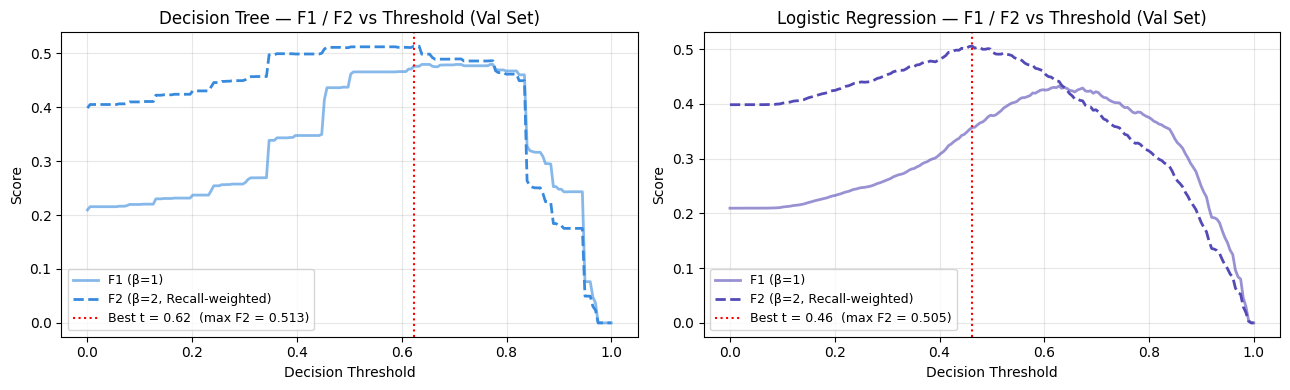

In [26]:
# ── Probabilities ─────────────────────────────────────────────────────────────
dt_proba_val  = dt.predict_proba(X_val)
dt_proba_test = dt.predict_proba(X_test)

lr_proba_val  = sigmoid(X_lr_val  @ lr_weights).flatten()
lr_proba_test = sigmoid(X_lr_test @ lr_weights).flatten()

# ── Threshold tuning (F2, validation set) ────────────────────────────────────
dt_best_t, dt_best_f2 = best_threshold_f2(y_val, dt_proba_val)
lr_best_t, lr_best_f2 = best_threshold_f2(y_val, lr_proba_val)

print(f"Decision Tree  — best threshold (val F2={dt_best_f2:.4f}): {dt_best_t:.3f}")
print(f"Logistic Reg.  — best threshold (val F2={lr_best_f2:.4f}): {lr_best_t:.3f}")

# ── Threshold sweep visualisation ────────────────────────────────────────────
thresholds = np.linspace(0.0, 1.0, 200)

def sweep_f1_f2(y_true, proba):
    f1s, f2s = [], []
    for t in thresholds:
        m = metrics(y_true, (proba >= t).astype(int))
        f1s.append(m["f1"]); f2s.append(m["f2"])
    return np.array(f1s), np.array(f2s)

dt_f1v, dt_f2v = sweep_f1_f2(y_val, dt_proba_val)
lr_f1v, lr_f2v = sweep_f1_f2(y_val, lr_proba_val)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, f1, f2, best_t, label, color in [
    (axes[0], dt_f1v, dt_f2v, dt_best_t, "Decision Tree", "#378ADD"),
    (axes[1], lr_f1v, lr_f2v, lr_best_t, "Logistic Regression", "#534AB7"),
]:
    ax.plot(thresholds, f1, color=color, lw=2, alpha=0.6, label="F1 (β=1)")
    ax.plot(thresholds, f2, color=color, lw=2, linestyle="--", label="F2 (β=2, Recall-weighted)")
    ax.axvline(best_t, color="red", linestyle=":", lw=1.5,
               label=f"Best t = {best_t:.2f}  (max F2 = {f2.max():.3f})")
    ax.set_xlabel("Decision Threshold"); ax.set_ylabel("Score")
    ax.set_title(f"{label} — F1 / F2 vs Threshold (Val Set)")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("comparison_threshold.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 6: Performance Metrics Comparison (Test Set)

All numbers below use the threshold tuned in Step 5. The test set was never used for any modelling decision.

In [27]:
dt_pred_test = (dt_proba_test >= dt_best_t).astype(int)
lr_pred_test = (lr_proba_test >= lr_best_t).astype(int)

dt_m = metrics(y_test, dt_pred_test)
lr_m = metrics(y_test, lr_pred_test)

# AUC values (threshold-independent)
_, dt_rec_te, dt_fpr_te, dt_auc_pr, dt_auc_roc = pr_roc_curves(y_test, dt_proba_test)
_, lr_rec_te, lr_fpr_te, lr_auc_pr, lr_auc_roc = pr_roc_curves(y_test, lr_proba_test)

# ALIFT for both models
def compute_alift(y_true, proba):
    sort_idx  = np.argsort(proba)[::-1]
    y_sorted  = y_true[sort_idx]
    n_pos     = int(y_true.sum())
    gains     = np.cumsum(y_sorted) / n_pos
    pct       = np.arange(1, len(y_true) + 1) / len(y_true)
    return float(np.trapezoid(gains, pct))

dt_alift = compute_alift(y_test, dt_proba_test)
lr_alift = compute_alift(y_test, lr_proba_test)

print("=" * 62)
print(f"  {'Metric':<20}  {'Decision Tree':>14}  {'Logistic Reg.':>14}")
print("=" * 62)
rows = [
    ("Threshold (tuned)",  f"{dt_best_t:.3f}",           f"{lr_best_t:.3f}"),
    ("Accuracy",           f"{dt_m['acc']:.4f}",          f"{lr_m['acc']:.4f}"),
    ("Precision",          f"{dt_m['prec']:.4f}",         f"{lr_m['prec']:.4f}"),
    ("Recall",             f"{dt_m['rec']:.4f}",          f"{lr_m['rec']:.4f}"),
    ("F1-Score",           f"{dt_m['f1']:.4f}",           f"{lr_m['f1']:.4f}"),
    ("F2-Score",           f"{dt_m['f2']:.4f}",           f"{lr_m['f2']:.4f}"),
    ("AUC-PR",             f"{dt_auc_pr:.4f}",            f"{lr_auc_pr:.4f}"),
    ("AUC-ROC",            f"{dt_auc_roc:.4f}",           f"{lr_auc_roc:.4f}"),
    ("ALIFT",              f"{dt_alift:.4f}",             f"{lr_alift:.4f}"),
]
for name, dt_val, lr_val in rows:
    better = "◀ DT" if (float(dt_val.replace("◀","").strip()) > float(lr_val.replace("◀","").strip()) and name != "Threshold (tuned)") else \
             ("◀ LR" if (float(lr_val) > float(dt_val) and name != "Threshold (tuned)") else "")
    print(f"  {name:<20}  {dt_val:>14}  {lr_val:>14}  {better}")
print("=" * 62)
print(f"  Random baseline: AUC-PR ≈ {y_test.mean():.3f}, AUC-ROC = 0.500, ALIFT = 0.500")

  Metric                 Decision Tree   Logistic Reg.
  Threshold (tuned)              0.623           0.462  
  Accuracy                      0.8581          0.6979  ◀ DT
  Precision                     0.4133          0.2281  ◀ DT
  Recall                        0.5099          0.6641  ◀ LR
  F1-Score                      0.4566          0.3395  ◀ DT
  F2-Score                      0.4872          0.4804  ◀ DT
  AUC-PR                        0.4177          0.4093  ◀ DT
  AUC-ROC                       0.7587          0.7542  ◀ DT
  ALIFT                         0.7290          0.7244  ◀ DT
  Random baseline: AUC-PR ≈ 0.117, AUC-ROC = 0.500, ALIFT = 0.500


## Step 7: Confusion Matrices (Side-by-Side)

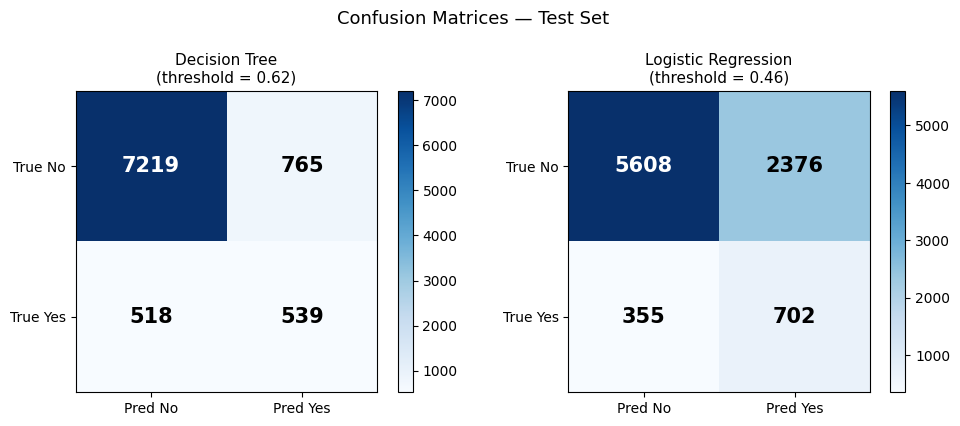


                       Decision Tree   Logistic Reg.
──────────────────────────────────────────────────────
  TP                             539             702
  FP                             765            2376
  TN                            7219            5608
  FN                             518             355


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, m, label, threshold in [
    (axes[0], dt_m, "Decision Tree",      dt_best_t),
    (axes[1], lr_m, "Logistic Regression", lr_best_t),
]:
    cm = np.array([[m["TN"], m["FP"]], [m["FN"], m["TP"]]])
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred No", "Pred Yes"])
    ax.set_yticklabels(["True No", "True Yes"])
    ax.set_title(f"{label}\n(threshold = {threshold:.2f})", fontsize=11)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    fontsize=15, fontweight="bold",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    plt.colorbar(im, ax=ax)

plt.suptitle("Confusion Matrices — Test Set", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("comparison_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# Print TP/FP/TN/FN side by side
print(f"\n{'':20}  {'Decision Tree':>14}  {'Logistic Reg.':>14}")
print("─" * 54)
for k in ["TP", "FP", "TN", "FN"]:
    print(f"  {k:<18}  {dt_m[k]:>14}  {lr_m[k]:>14}")

## Step 8: PR Curve and ROC Curve Comparison

Threshold-independent curves show which model has better overall discrimination regardless of the specific operating point chosen.

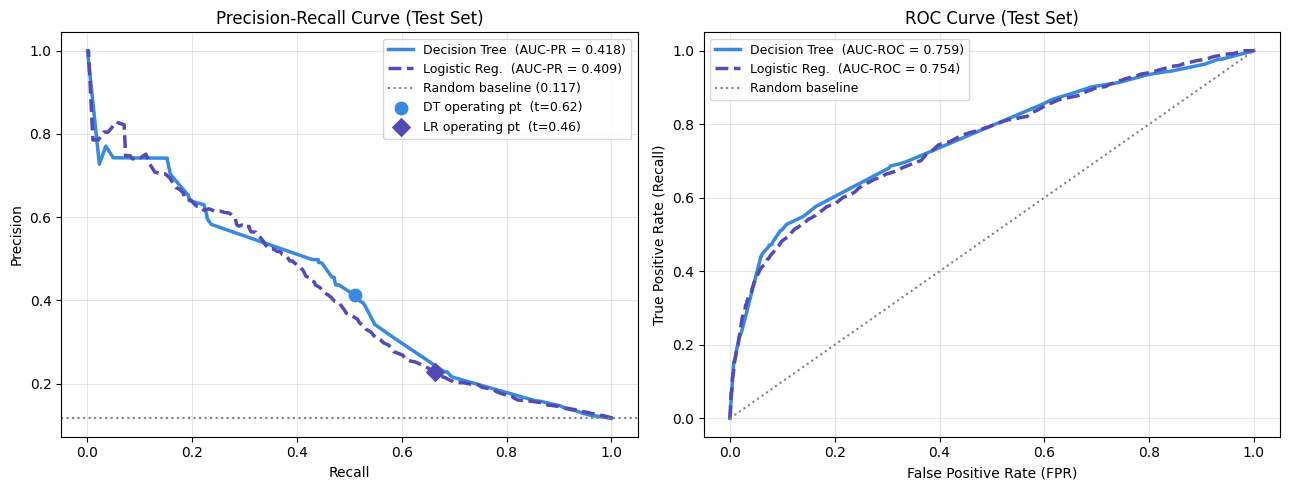

In [29]:
dt_prec_te, dt_rec_te2, dt_fpr_te2, _, _ = pr_roc_curves(y_test, dt_proba_test)
lr_prec_te, lr_rec_te2, lr_fpr_te2, _, _ = pr_roc_curves(y_test, lr_proba_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
baseline_pr = float(y_test.mean())

# ── PR Curve ─────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(dt_rec_te2, dt_prec_te, color="#378ADD", lw=2.5,
        label=f"Decision Tree  (AUC-PR = {dt_auc_pr:.3f})")
ax.plot(lr_rec_te2, lr_prec_te, color="#534AB7", lw=2.5, linestyle="--",
        label=f"Logistic Reg.  (AUC-PR = {lr_auc_pr:.3f})")
ax.axhline(baseline_pr, color="gray", linestyle=":", lw=1.5,
           label=f"Random baseline ({baseline_pr:.3f})")
# Mark operating points
dt_prec_op, dt_rec_op = dt_m["prec"], dt_m["rec"]
lr_prec_op, lr_rec_op = lr_m["prec"], lr_m["rec"]
ax.scatter([dt_rec_op], [dt_prec_op], color="#378ADD", s=80, zorder=5,
           label=f"DT operating pt  (t={dt_best_t:.2f})")
ax.scatter([lr_rec_op], [lr_prec_op], color="#534AB7", s=80, marker="D", zorder=5,
           label=f"LR operating pt  (t={lr_best_t:.2f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve (Test Set)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── ROC Curve ────────────────────────────────────────────────────────────────
ax = axes[1]
# Sort for clean lines
dt_sort = np.argsort(dt_fpr_te2); lr_sort = np.argsort(lr_fpr_te2)
ax.plot(dt_fpr_te2[dt_sort], dt_rec_te2[dt_sort], color="#378ADD", lw=2.5,
        label=f"Decision Tree  (AUC-ROC = {dt_auc_roc:.3f})")
ax.plot(lr_fpr_te2[lr_sort], lr_rec_te2[lr_sort], color="#534AB7", lw=2.5, linestyle="--",
        label=f"Logistic Reg.  (AUC-ROC = {lr_auc_roc:.3f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle=":", lw=1.5, label="Random baseline")
ax.set_xlabel("False Positive Rate (FPR)"); ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("ROC Curve (Test Set)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("comparison_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 9: Feature Importance Comparison

**Decision Tree** importance = normalised mean decrease in Gini impurity (MDI), weighted by the fraction of samples reaching each node.

**Logistic Regression** importance = absolute value of the learned weight for each feature. The sign indicates direction of effect.

The top 15 features for each model are shown; they need not overlap.

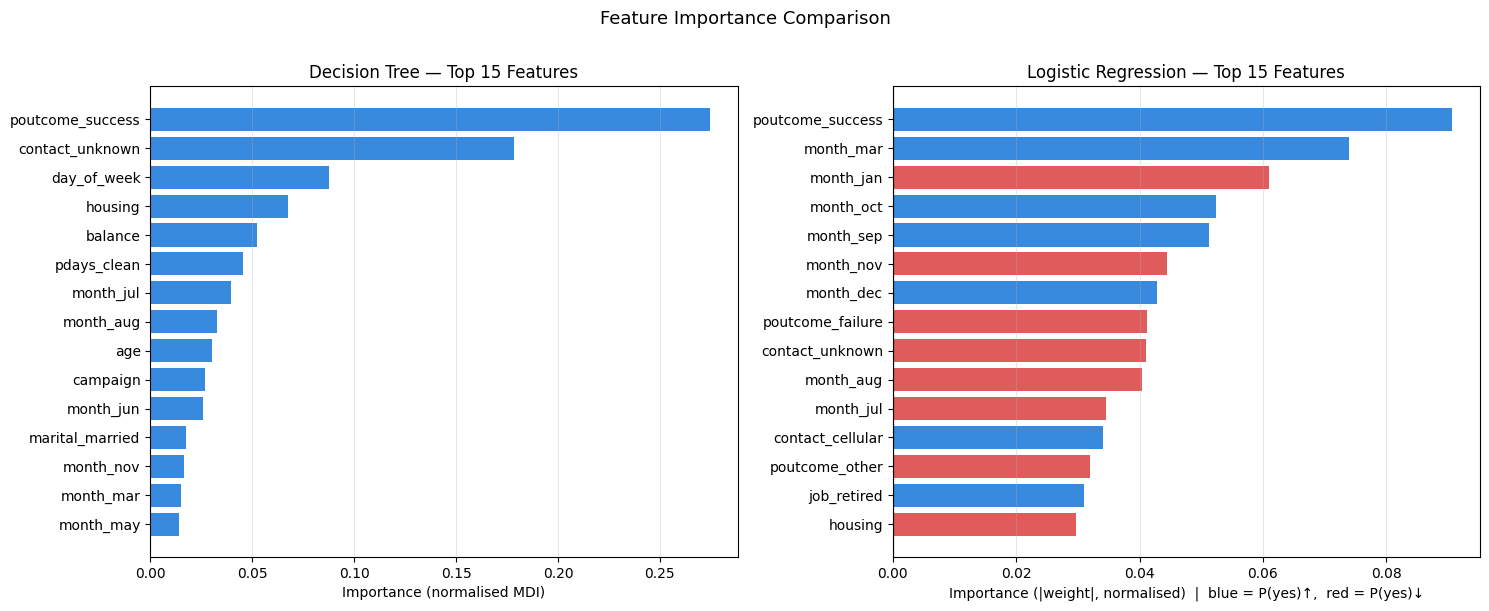


Features in BOTH top-15 lists (7):
  contact_unknown
  housing
  month_aug
  month_jul
  month_mar
  month_nov
  poutcome_success


In [30]:
def dt_feature_importances(node, n_feat, n_total, imp=None):
    if imp is None: imp = np.zeros(n_feat)
    if "label" in node: return imp
    imp[node["feature"]] += (node["n_samples"] / n_total) * node["gini_gain"]
    dt_feature_importances(node["left"],  n_feat, n_total, imp)
    dt_feature_importances(node["right"], n_feat, n_total, imp)
    return imp

n_feat = X_all.shape[1]
raw_dt_imp = dt_feature_importances(dt.tree, n_feat, len(y_train))
dt_imp = raw_dt_imp / raw_dt_imp.sum()

lr_imp_raw = lr_weights[1:].flatten()   # exclude bias
lr_imp_abs = np.abs(lr_imp_raw)
lr_imp_abs = lr_imp_abs / lr_imp_abs.sum()

top_n = 15
dt_top_idx = np.argsort(dt_imp)[::-1][:top_n]
lr_top_idx = np.argsort(lr_imp_abs)[::-1][:top_n]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Decision Tree ─────────────────────────────────────────────────────────────
ax = axes[0]
names = [feature_names[i] for i in dt_top_idx]
vals  = [dt_imp[i]        for i in dt_top_idx]
ax.barh(names[::-1], vals[::-1], color="#378ADD")
ax.set_xlabel("Importance (normalised MDI)")
ax.set_title("Decision Tree — Top 15 Features")
ax.grid(axis="x", alpha=0.3)

# ── Logistic Regression ───────────────────────────────────────────────────────
ax = axes[1]
names_lr = [feature_names[i] for i in lr_top_idx]
raw_w    = [lr_imp_raw[i]    for i in lr_top_idx]  # signed, for direction
colors   = ["#378ADD" if w > 0 else "#E05C5C" for w in raw_w]
ax.barh(names_lr[::-1], [lr_imp_abs[i] for i in lr_top_idx][::-1],
        color=colors[::-1])
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Importance (|weight|, normalised)  |  blue = P(yes)↑,  red = P(yes)↓")
ax.set_title("Logistic Regression — Top 15 Features")
ax.grid(axis="x", alpha=0.3)

plt.suptitle("Feature Importance Comparison", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("comparison_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# Overlap
dt_top_set = set(feature_names[i] for i in dt_top_idx)
lr_top_set = set(feature_names[i] for i in lr_top_idx)
overlap = dt_top_set & lr_top_set
print(f"\nFeatures in BOTH top-15 lists ({len(overlap)}):")
for f in sorted(overlap):
    print(f"  {f}")

## Step 10: Cumulative Gains (ALIFT) Comparison

Ranking customers by predicted probability and calling from highest to lowest, how quickly do we accumulate true subscribers? A model with a higher cumulative gains curve reaches more subscribers with fewer calls.

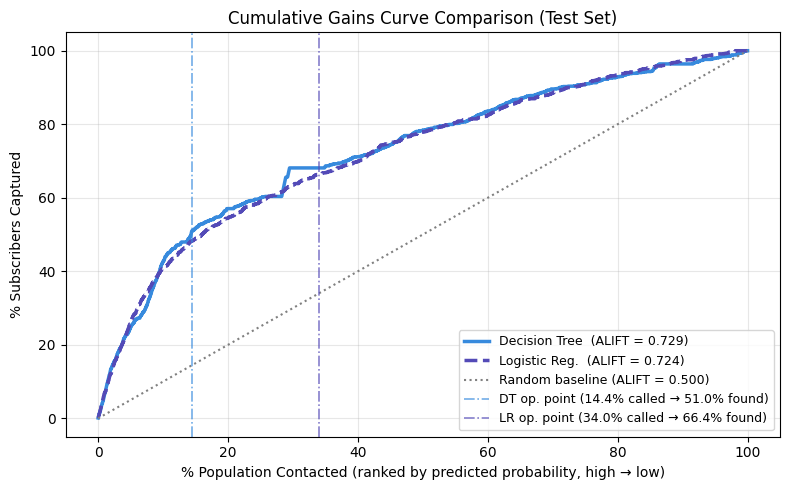


  Decile   DT Recall   DT Lift   LR Recall   LR Lift
────────────────────────────────────────────────────────
 Top 10%       0.427      4.27       0.408      4.08
 Top 20%       0.570      2.85       0.545      2.72
 Top 30%       0.681      2.27       0.635      2.12
 Top 40%       0.711      1.78       0.698      1.75
 Top 50%       0.783      1.57       0.779      1.56
 Top 60%       0.835      1.39       0.824      1.37
 Top 70%       0.896      1.28       0.885      1.26
 Top 80%       0.929      1.16       0.936      1.17
 Top 90%       0.964      1.07       0.974      1.08
Top 100%       1.000      1.00       1.000      1.00


In [31]:
def gains_curve(y_true, proba):
    idx      = np.argsort(proba)[::-1]
    ys       = y_true[idx]
    n_pos    = int(y_true.sum())
    n_total  = len(y_true)
    pct_pop  = np.arange(1, n_total + 1) / n_total * 100
    gains    = np.cumsum(ys) / n_pos * 100
    return pct_pop, gains

dt_pct, dt_gains = gains_curve(y_test, dt_proba_test)
lr_pct, lr_gains = gains_curve(y_test, lr_proba_test)

# Operating-point percentages at tuned thresholds
dt_op_pct = (dt_proba_test >= dt_best_t).sum() / len(y_test) * 100
lr_op_pct = (lr_proba_test >= lr_best_t).sum() / len(y_test) * 100

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(dt_pct, dt_gains, color="#378ADD", lw=2.5,
        label=f"Decision Tree  (ALIFT = {dt_alift:.3f})")
ax.plot(lr_pct, lr_gains, color="#534AB7", lw=2.5, linestyle="--",
        label=f"Logistic Reg.  (ALIFT = {lr_alift:.3f})")
ax.plot([0, 100], [0, 100], color="gray", linestyle=":", lw=1.5, label="Random baseline (ALIFT = 0.500)")
ax.axvline(dt_op_pct, color="#378ADD", linestyle="-.", lw=1.2, alpha=0.7,
           label=f"DT op. point ({dt_op_pct:.1f}% called → {dt_gains[int(dt_op_pct/100*len(y_test))-1]:.1f}% found)")
ax.axvline(lr_op_pct, color="#534AB7", linestyle="-.", lw=1.2, alpha=0.7,
           label=f"LR op. point ({lr_op_pct:.1f}% called → {lr_gains[int(lr_op_pct/100*len(y_test))-1]:.1f}% found)")
ax.set_xlabel("% Population Contacted (ranked by predicted probability, high → low)")
ax.set_ylabel("% Subscribers Captured")
ax.set_title("Cumulative Gains Curve Comparison (Test Set)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Decile table
print(f"\n{'Decile':>8}  {'DT Recall':>10}  {'DT Lift':>8}  {'LR Recall':>10}  {'LR Lift':>8}")
print("─" * 56)
base_rate = float(y_test.mean())
n_tot = len(y_test)
dt_s = np.argsort(dt_proba_test)[::-1]; dt_ys = y_test[dt_s]
lr_s = np.argsort(lr_proba_test)[::-1]; lr_ys = y_test[lr_s]
n_pos_test = int(y_test.sum())
for pct in range(10, 110, 10):
    k = int(n_tot * pct / 100)
    dt_rec = dt_ys[:k].sum() / n_pos_test
    lr_rec = lr_ys[:k].sum() / n_pos_test
    dt_lift = (dt_ys[:k].sum() / k) / base_rate
    lr_lift = (lr_ys[:k].sum() / k) / base_rate
    print(f"{'Top '+str(pct)+'%':>8}  {dt_rec:>10.3f}  {dt_lift:>8.2f}  {lr_rec:>10.3f}  {lr_lift:>8.2f}")

## Step 11: Summary and Model Selection

### Evaluation Protocol

| Setting | Both Models |
|---------|-------------|
| Dataset | `cleaned_data.csv` (45,211 samples, 48 features) |
| Split | 64 % train / 16 % val / 20 % test, stratified |
| Optimisation target | F2-score (β=2) |
| Threshold | Tuned on validation set, evaluated on test set |

---

### Decision Matrix

| Criterion | Decision Tree | Logistic Regression |
|-----------|:---:|:---:|
| Handles non-linear patterns | ✅ | ❌ |
| Interpretable decision rules | ✅ (tree path) | ✅ (weights) |
| Convergence guarantee | ❌ (heuristic) | ✅ (convex loss) |
| Risk of overfitting | Higher | Lower |
| Training speed (this dataset) | Slower | Faster |
| AUC-PR / AUC-ROC | see Step 6 output | see Step 6 output |
| ALIFT | see Step 6 output | see Step 6 output |

---

### When to prefer each model

**Choose Decision Tree if:**
- AUC-PR or AUC-ROC is higher (captures more non-linear signal from `poutcome`, `contact_unknown`, etc.)
- Business users need to understand "why was this customer flagged?" — tree paths are intuitive

**Choose Logistic Regression if:**
- Performance is comparable but training is constrained by time or compute
- The relationship between features and subscription is largely additive/linear
- You need well-calibrated probabilities for risk scoring

---

### Key shared finding

Both models agree that `poutcome_success` (previous campaign outcome = success) and `contact_unknown` (unknown contact type) are the most discriminative features, confirming that **past behaviour and reachability dominate subscription likelihood** more than demographic or financial characteristics.